In [1]:
import pandas as pd
import numpy as np
from scipy.stats import entropy, skew, kurtosis, iqr
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

In [2]:
DATA_DIR = Path('data')

Define target activity directories

In [3]:
idle = DATA_DIR / 'idle'
running = DATA_DIR / 'running'
walking = DATA_DIR / 'walking'
stairs = DATA_DIR / 'stairs'

Function that calculates a Signal Magnitude Area (SMA)

In [4]:
def signal_magnitude_area(data_x,data_y,data_z):
    abs_sum = np.sum(np.abs(data_x)) + np.sum(np.abs(data_y)) + np.sum(np.abs(data_z))
    n = len(data_x)
    if n == 0:
        sma = 0
    else:
        sma = (1 / n) * abs_sum
    return sma

Function to find power and energy values

In [5]:
def calculate_energy_power(data_x,data_y,data_z):
    # The number of data samples in my time window
    n = len(data_x)
    
    # Firstly, Signal Magnitude Vector must be calculated
    smv = np.sqrt(np.power(data_x,2) + np.power(data_y,2) + np.power(data_z,2))
        
    # Secondly, the mean SMV of this window must be calculated
    smv_mean = smv.mean()
    
    # Finally, the signal energy and power is calculated
    energy = float(np.sum((smv - smv_mean)**2))
    
    power = float((1 / n) * energy)
    
    return energy, power

Function to find the entrophy

In [6]:
def find_entrophy(data):
# 1. Find the amount of bins:
    bins_d = int(np.log(len(data) + 1))
    counts, _ = np.histogram(data, bins=bins_d)
    probs = counts / np.sum(counts)
    entr = float(entropy(probs,base=2))
    return entr

Function that extracts all features and adds them in the dictionary

In [7]:
def extract_all_features(df, activity):
    features = {}
    x = df['accelerometer_X'].values
    y = df['accelerometer_Y'].values
    z = df['accelerometer_Z'].values
    axes = {'X': x, 'Y': y, 'Z':z}
    for axis_name, data in axes.items():
        ### find mean value 
        features[f'mean_{axis_name}'] = data.mean()
        
        ## find standard deviation
        features[f'std_{axis_name}'] = data.std()
        
        ## find varience value 
        features[f'var_{axis_name}'] = data.var()
        
        # find median value 
        features[f'median_{axis_name}'] = np.median(data)
        
        # find minimum value
        features[f'min_{axis_name}'] = data.min()
        
        # find maximum value 
        features[f'max_{axis_name}'] = data.max()
        
        # find root main square metric
        features[f'rms_{axis_name}'] = np.sqrt(np.mean(data**2))
        
        # find indexes of minimum values
        features[f'idx_min_{axis_name}'] = data.argmin()
        
        # find indexes of maximum values
        features[f'idx_max_{axis_name}'] = data.argmax()
        
        # find the entrophy 
        features[f'entropy_{axis_name}'] = find_entrophy(data)
        
        # calculate skewness
        features[f'skewness_{axis_name}'] = skew(data)
        
        # calculate the kurtosis
        features[f'kurtosis_{axis_name}'] = kurtosis(data)
        
        # # calculate the Interquartile Range або IQR
        features[f'iqr_{axis_name}'] = iqr(data)
        
        # calculate mean absolute deviation
        features[f'mad_{axis_name}'] = np.mean(np.abs(data - data.mean())) 
            
    # find power and energy values
    features['energy'],features['power'] = calculate_energy_power(x,y,z)

    # find Signal Magnitude Area (SMA)
    features['sma'] = signal_magnitude_area(x,y,z)

    # calculate correlation of binary combinations of x, y, and z. 
    x_norm = (x - x.mean()) / x.std()
    y_norm = (y - y.mean()) / y.std()
    z_norm = (z - z.mean()) / z.std()

    features['xy_corr'] = np.dot(x_norm,y_norm) / len(x)
    features['yz_corr'] = np.dot(y_norm,z_norm) / len(x)
    features['xz_corr'] = np.dot(x_norm,z_norm) / len(x)

    features['activity'] = activity
    return features

Extracts time-domain features from all files in a directory and compiles them into a DataFrame

In [8]:
def create_df(path, activity):
    rows = []
    files_list = list(path.iterdir())
    idle_length = len(files_list)
    for file in files_list:
    
        if file.is_file():
            file_obj = pd.read_csv(file)
            feat = extract_all_features(file_obj, activity)
            rows.append(feat)
    df = pd.DataFrame(rows)
    return df

Create the DataFrame for each path and unite them in the final DataFrame

In [9]:
idle = create_df(idle, 'idle')
running = create_df(running, 'running')
walking = create_df(walking, 'walking')
stairs = create_df(stairs, 'stairs')
final_df = pd.concat([idle,running,walking,stairs],ignore_index=True)
final_df

,mean_X,std_X,var_X,median_X,min_X,max_X,rms_X,idx_min_X,idx_max_X,entropy_X,...,kurtosis_Z,iqr_Z,mad_Z,energy,power,sma,xy_corr,yz_corr,xz_corr,activity
0,-0.060813,0.330578,0.109282,-0.043095,-0.885855,0.828394,0.336125,22,29,1.241946,...,0.732424,0.533907,0.346616,2.029458,0.067649,13.911589,-0.132054,-0.636990,0.176976,idle
1,-0.066878,0.361401,0.130611,-0.057461,-0.885855,0.828394,0.367537,10,17,1.418620,...,-0.738323,0.752976,0.390457,2.236303,0.074543,14.060509,0.233055,-0.626861,0.232341,idle
2,0.267512,0.069947,0.004893,0.260968,0.162806,0.440533,0.276506,8,15,1.429473,...,0.113806,0.016759,0.015493,0.013436,0.000448,10.078472,-0.053204,0.050189,-0.063746,idle
3,0.264320,0.212522,0.045166,0.258574,-0.373495,1.010353,0.339162,9,17,0.699843,...,9.570541,0.019154,0.020048,0.021447,0.000715,10.175836,0.697684,-0.101484,-0.654687,idle
4,0.301669,0.162091,0.026273,0.265756,0.172383,1.010353,0.342458,0,5,0.353359,...,10.445808,0.019154,0.019441,0.018251,0.000608,10.146627,0.455495,-0.578407,-0.872000,idle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6456,-0.268150,3.339632,11.153140,-0.179565,-7.426813,5.272033,3.350380,27,25,1.474679,...,2.127992,5.505467,4.348190,1099.224891,36.640830,19.296468,-0.129043,0.136208,-0.312751,stairs
6457,-0.410206,3.783048,14.311450,-0.074220,-9.528923,5.272033,3.805223,26,13,1.418320,...,1.566871,5.949591,4.520891,1340.342615,44.678087,20.024145,0.046846,0.127379,-0.353524,stairs
6458,1.025197,2.729689,7.451200,0.919373,-4.769250,5.880160,2.915858,15,3,1.565596,...,5.207819,3.495534,3.306871,665.633646,22.187788,14.872143,-0.171637,0.460355,-0.290461,stairs
6459,-3.485958,3.079463,9.483093,-2.961627,-10.036493,2.987964,4.651343,14,27,1.418620,...,0.168998,3.233370,1.898996,540.518314,18.017277,15.618335,0.454358,0.218130,-0.066166,stairs


In [10]:
final_df.shape[1]

49

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

The figure below illustrates that power and energy show identical patterns because power = energy / n.
Both features effectively capture movement intensity.
Running shows highest values with wide spread indicating explosive, variable motion.
Idle is near-zero confirming the sensor barely moves.

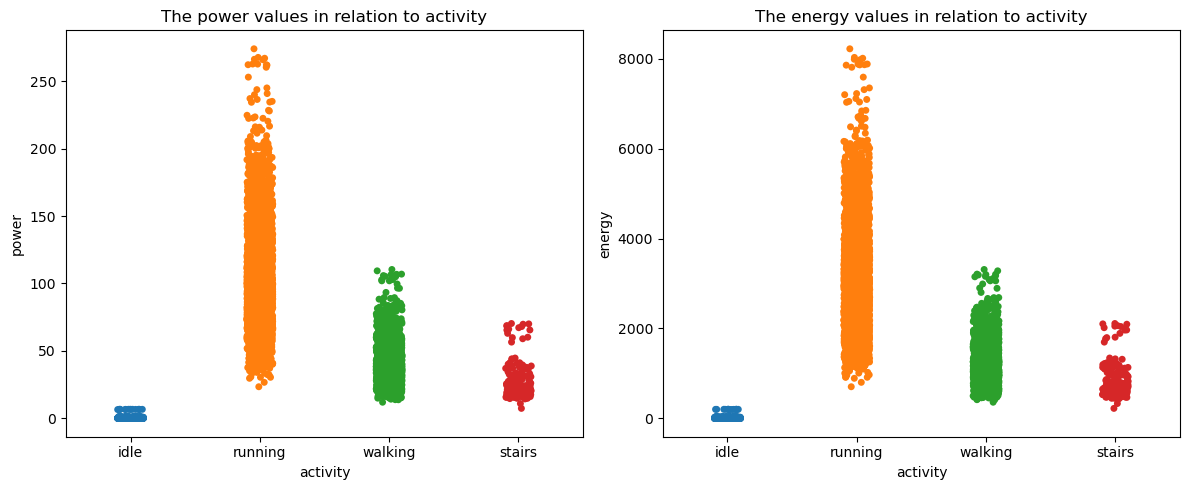

In [12]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))
sns.stripplot(x='activity', y='power', hue='activity',data=final_df ,ax = axs[0])
axs[0].set_title('The power values in relation to activity')
sns.stripplot(x='activity', y='energy', hue='activity',data=final_df ,ax = axs[1])
axs[1].set_title('The energy values in relation to activity')
plt.tight_layout()
plt.show()

This plot reveals that the energy value rises when the SMA value rises too, demonstrating a strong linear dependency between these two features.

Key observations:
1. idle (blue) clusters tightly at the bottom left: very low SMA and energy, confirming minimal movement.
2. running (orange) dominates the top right: highest intensity, wide spread showing variable movement patterns.
3. walking (green) and stairs (red) overlap significantly in the middle range: this suggests these two activities may be harder for the model to distinguish.
4. The strong correlation between SMA and energy suggests these features carry similar information: one of them could potentially be dropped during feature selection without losing much predictive power. 

<Axes: xlabel='sma', ylabel='energy'>

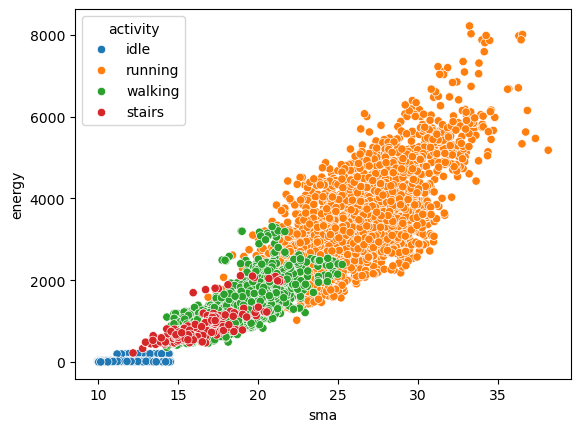

In [13]:
sns.scatterplot(x='sma', y='energy', hue='activity',data=final_df)

The next graph illustrates a correlation matrix between features and visually groups similar features into coloured blocks. 

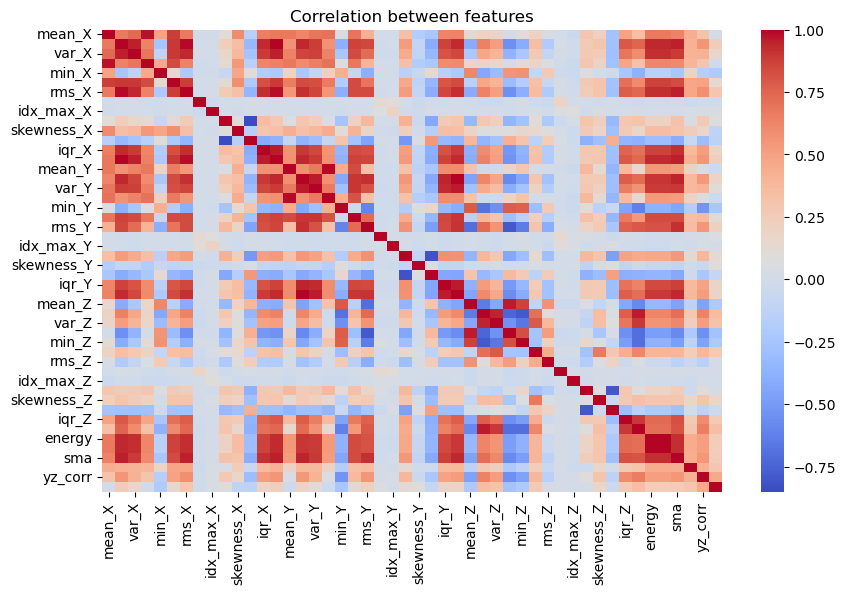

In [14]:
corr_matrix = final_df.drop(columns='activity').corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f")
plt.title("Correlation between features")
plt.show()

The t-SNE Projection of extracted features by activity types

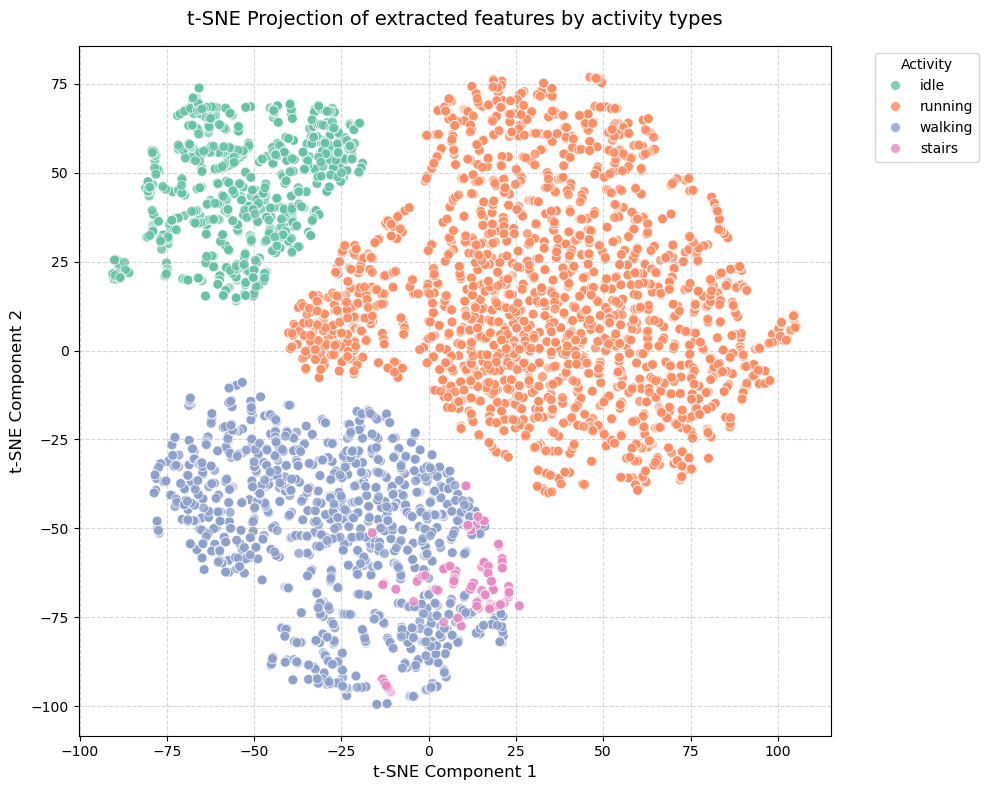

In [15]:

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

X = final_df.drop(columns='activity')
y = final_df['activity']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame(X_tsne, columns=['t-SNE Component 1', 't-SNE Component 2'])
df_tsne['activity'] = y.values

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_tsne, 
    x='t-SNE Component 1', 
    y='t-SNE Component 2', 
    hue='activity', 
    palette='Set2',
    alpha=0.8,      
    s=50            
)

plt.title('t-SNE Projection of extracted features by activity types', fontsize=14, pad=15)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.legend(title='Activity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

This t-SNE graph shows how effectively our engineered features separate different human activities before training a classifier. By compressing over 40 complex parameters into a 2D plane, t-SNE reveals distinct clusters for different movements. This clear separation proves that the dataset has high predictive power for the upcoming machine learning model, presenting some difficulties in identifying walking and stairs activity. 

The Radar Chart

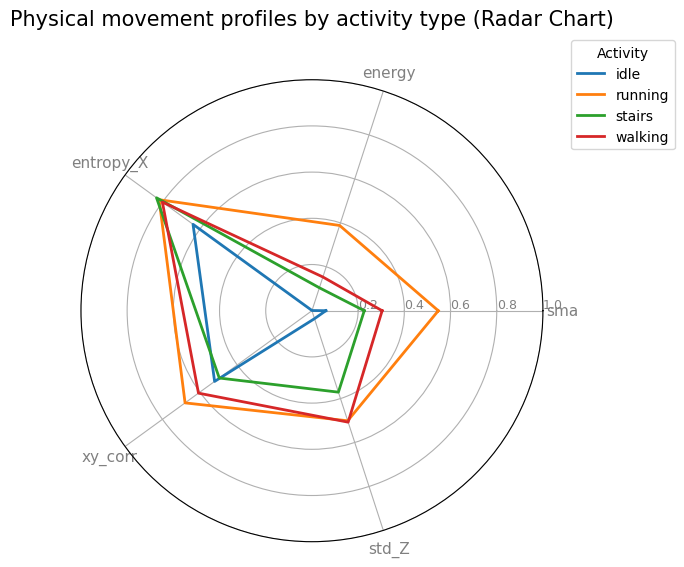

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
features_to_select=['sma','energy','entropy_X','xy_corr','std_Z']
# 1. Scale necessary columns ( get NumPy array) 
scaled_array = scaler.fit_transform(X[features_to_select])

# 2. Transform an array to the DataFrame
scaled_df = pd.DataFrame(scaled_array,columns=features_to_select)

# 3. Add y values to the DataFrame 
scaled_df['activity'] = y.values

# 4. Group the DataFrame and calculate mean values 
radar_df = scaled_df.groupby('activity').mean()
radar_df

# Building a Radar Chart
# 1. Define features and angles
categories = list(radar_df.columns)
num_vars = len(categories)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# 2. Create Loop Closing
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection='polar'))

plt.xticks(angles[:-1], categories, color='grey', size=11)

# 3. Limit radius from 0 to 1
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=9)
plt.ylim(0, 1)

# 4. Iterate over each row  in the dataframe
for activity_name, row in radar_df.iterrows():
    values = row.values.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=activity_name)
plt.title('Physical movement profiles by activity type (Radar Chart)', size=15, color='black', y=1.1)
plt.legend(title='Activity', loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

The Radar Chart demonstrates to us several points:
1. Stairs and walking types have identical geometrical form, but the green polygon is a bit smaller except xy_corr and std_Z values.
   Conclusion: Stairs and walking are very cyclic movements which overlap and create the biggest challenge for th model to define         them.
2. Running type has significantly larger sma and energy values in comparison to other types, while std_Z values differ between walking    and stairs.
   Conclusion: Sma, energy and std_Z are important features that cannot be removed in fitting our model because they help us to           distinguish activities.
3. Three points converged roughly at the same point on the entrophy_X ray.
   Conclusion: The entrophy_X feature does not bring significant value to the model and can be removed. 

The Overlapping KDE Plot (Kernel Density Estimate Plot) 

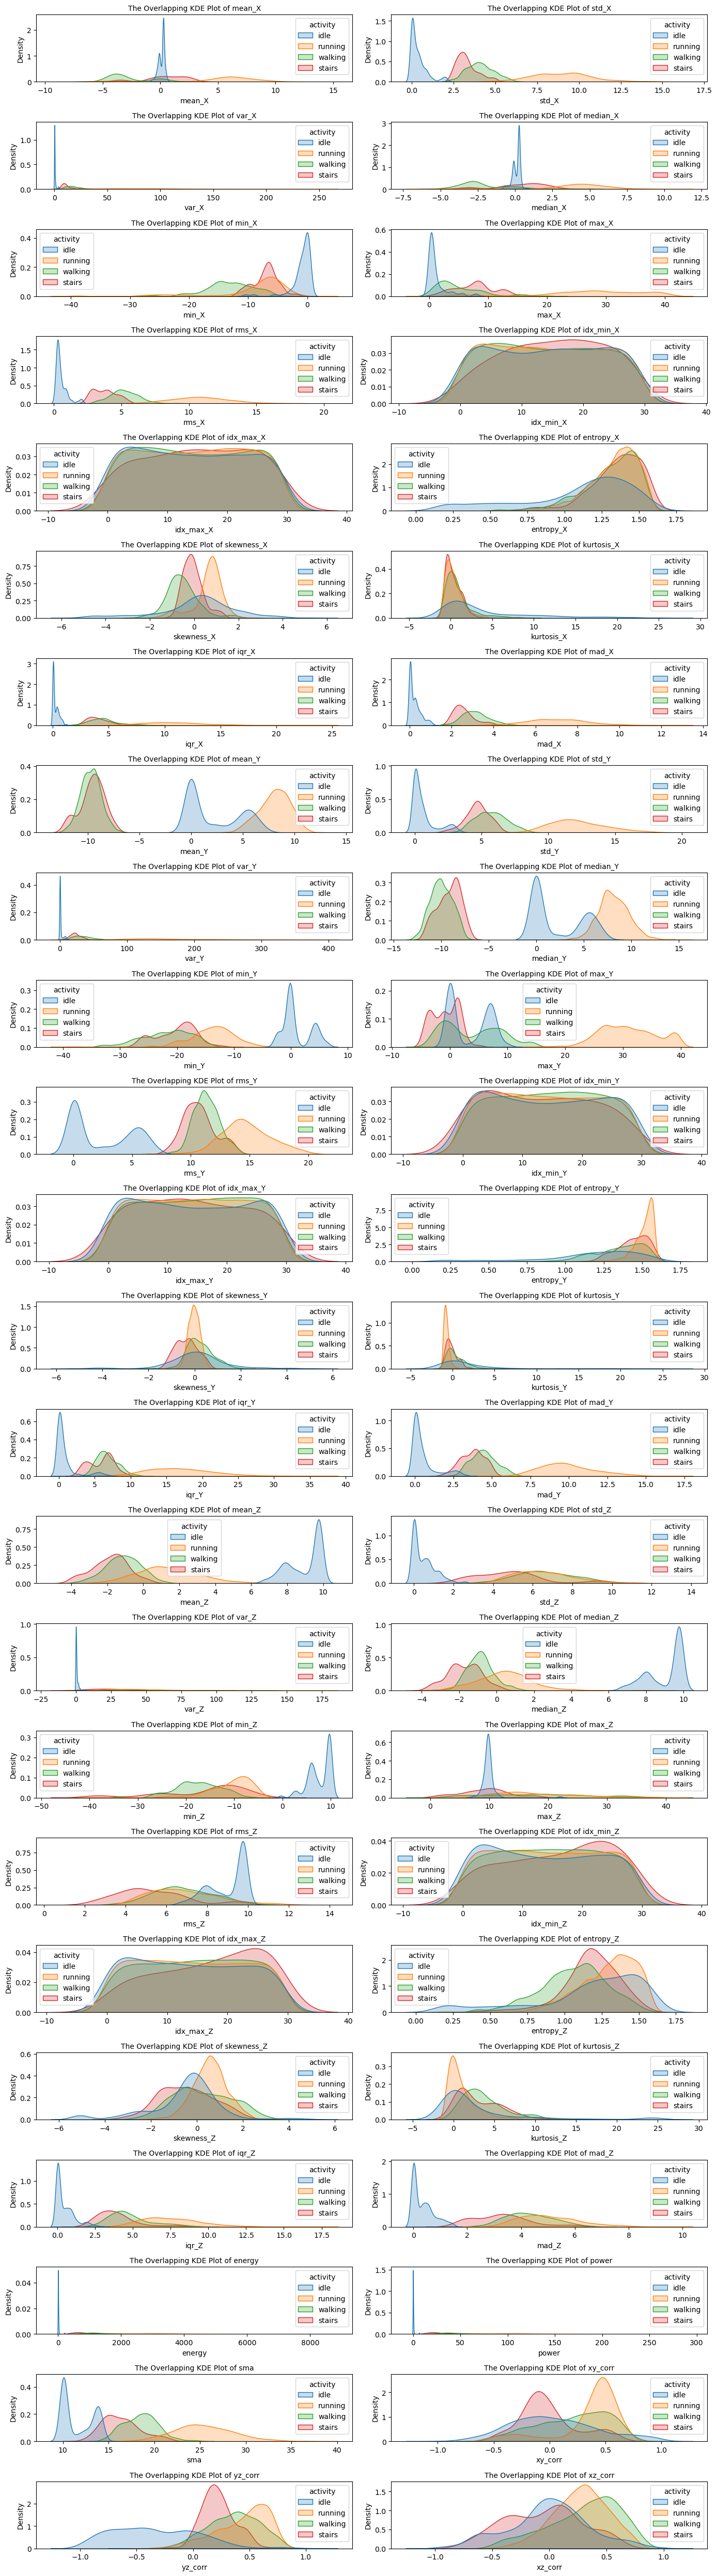

In [17]:
final_df_copy = final_df.copy()
features = list(final_df_copy.drop(columns='activity').columns.values)
figure, axes = plt.subplots(24,2, figsize=(14, 50))
axes = axes.flatten() 
for index, item in enumerate(features):
    sns.kdeplot(final_df_copy, x=item, hue='activity', fill=True,common_norm=False, ax=axes[index])
    axes[index].set_title(f'The Overlapping KDE Plot of {item}', fontsize=10)

plt.tight_layout()
plt.show()

The Overlapping KDE Plot (Kernel Density Estimate Plot) is built in order to notice how well each single metric splits our activities. 

Using SVM algorithm

1. Using all features:

In [18]:
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, hinge_loss, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV

X = final_df.drop(columns='activity')
y = final_df['activity']

scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42,shuffle=True)

scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

Building and finding most suitable model

In [19]:
parameters = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10]
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.1, 1]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10],
        'degree': [2, 3, 4],
        'gamma': ['scale']
    }
]
svc = svm.SVC()

Function that checks metrics 

In [20]:
def calculate_metrics(clf, X_test, y_test, y_pred,average='macro'):
    
    ### Metrics
  # 1. Accuracy
    accuracy = round(accuracy_score(y_test, y_pred)*100,2)

  # 2. Loss function
    if hasattr(clf, 'decision_function'): 
        pred_decisions = clf.decision_function(X_test)
        loss = hinge_loss(y_test, pred_decisions)
    else:
        loss=None

  # 3. Precision
    precision = precision_score(y_test, y_pred, average=average)

  # 4. Recall
    recall = recall_score(y_test, y_pred,average=average)

  # 5. F1-Score
    f1 = f1_score(y_test, y_pred, average=average)

  # 6. Classification report 
    cr = classification_report(y_test, y_pred)
    cr_dict = classification_report(y_test, y_pred,output_dict=True)
    return accuracy,loss,precision,recall,f1,cr,cr_dict

In [21]:
def compare_metrics_raw_scaled(title,accuracy_r,accuracy_s,loss_r,loss_l,precision_r,precision_s,recall_r,recall_s,f1_r,f1_s,cr_r,cr_s):
    print(title)
    print(f'Overall Model Accuracy with Raw Data: {accuracy_r}%')
    print(f'Overall Model Accuracy with Scaled Data: {accuracy_s}%\n')
    if loss_r != None and loss_l != None:
        print(f'Overall Model Loss with Raw Data: {loss_r}')
        print(f'Overall Model Loss with Scaled Data: {loss_l}\n')

    print(f'Overall Model Precision with Raw Data: {round(precision_r*100,2)}%')
    print(f'Overall Model Precision with Scaled Data: {round(precision_s*100,2)}%\n')

    print(f'Overall Model Recall with Raw Data: {round(recall_r*100,2)}%')
    print(f'Overall Model Recall with Scaled Data: {round(recall_s*100,2)}%\n')

    print(f'Overall Model F1-Score with Raw Data: {round(f1_r*100,2)}%')
    print(f'Overall Model F1-Score with Scaled Data: {round(f1_s*100,2)}%\n')

    print('Classification report for Raw Data:\n', cr_r)
    print('Classification report for Scaled Data:\n', cr_s)

Unscaled Model

In [22]:
clf_l_raw = GridSearchCV(svc,parameters)
clf_l_raw.fit(X_train,y_train)
y_pred_r = clf_l_raw.predict(X_test)

### Metrics
accuracy_r, loss_r,precision_r,recall_r,f1_r,cr_r,cr_r_dict = calculate_metrics(clf_l_raw, X_test, y_test, y_pred_r,average='macro')

Scaled Model

In [23]:
clf_l_scaled = GridSearchCV(svc,parameters)
clf_l_scaled.fit(scaled_X_train,y_train)
y_pred_s = clf_l_scaled.predict(scaled_X_test)

accuracy_s,loss_l,precision_s,recall_s,f1_s,cr_s, cr_s_dict = calculate_metrics(clf_l_scaled, scaled_X_test, y_test, y_pred_s,average='macro')

Comparison metrics of the model between raw and scaled data

In [24]:
title = 'Comparison metrics of SVM model between raw and scaled data'
compare_metrics_raw_scaled(title,accuracy_r,accuracy_s,loss_r,loss_l,precision_r,precision_s,recall_r,recall_s,f1_r,f1_s,cr_r,cr_s)

Comparison metrics of SVM model between raw and scaled data
Overall Model Accuracy with Raw Data: 99.69%
Overall Model Accuracy with Scaled Data: 99.88%

Overall Model Loss with Raw Data: 0.012487913658247533
Overall Model Loss with Scaled Data: 0.002824527016696406

Overall Model Precision with Raw Data: 98.15%
Overall Model Precision with Scaled Data: 99.89%

Overall Model Recall with Raw Data: 98.65%
Overall Model Recall with Scaled Data: 98.81%

Overall Model F1-Score with Raw Data: 98.4%
Overall Model F1-Score with Scaled Data: 99.34%

Classification report for Raw Data:
               precision    recall  f1-score   support

        idle       1.00      1.00      1.00       274
     running       1.00      1.00      1.00       834
      stairs       0.93      0.95      0.94        42
     walking       1.00      0.99      0.99       466

    accuracy                           1.00      1616
   macro avg       0.98      0.99      0.98      1616
weighted avg       1.00      1.00   

In [25]:
clf_l_raw.best_params_, clf_l_scaled.best_params_

({'C': 1, 'kernel': 'linear'}, {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'})

In [26]:
clf_l_raw.best_score_, clf_l_scaled.best_score_

(np.float64(0.996078431372549), np.float64(0.9989680082559339))

In [27]:
comparison_svm_df = pd.DataFrame({'Metric':['Accuracy', 'Loss','Presicion','Recall','F1-Score'], 'SMV_raw_data': [accuracy_r, loss_r,precision_r,recall_r,f1_r],'SMV_scaled_data': [accuracy_s,loss_l,precision_s,recall_s,f1_s]})
comparison_svm_df

,Metric,SMV_raw_data,SMV_scaled_data
0,Accuracy,99.690000,99.880000
1,Loss,0.012488,0.002825
2,Presicion,0.981483,0.998932
3,Recall,0.986486,0.988095
4,F1-Score,0.983951,0.993367


SMV model with scaled data provided better characteristics: Higher Accuracy, Lower Loss, Higher Precision, Higher Recall and Higher F1-score. While individual characteristics for both idle and running are similar in both models, stairs and walking performed much better on the SVM scaled model. Therefore, for futher comparisons, clf_l_scaled will be used.  

In [28]:
df_classification_svm = pd.DataFrame(cr_s_dict).transpose()
df_classification_svm

,precision,recall,f1-score,support
idle,1.000000,1.000000,1.000000,274.000000
running,1.000000,1.000000,1.000000,834.000000
stairs,1.000000,0.952381,0.975610,42.000000
walking,0.995726,1.000000,0.997859,466.000000
accuracy,0.998762,0.998762,0.998762,0.998762
macro avg,0.998932,0.988095,0.993367,1616.000000
weighted avg,0.998768,0.998762,0.998749,1616.000000


Random Forest

Raw Data

In [29]:
from sklearn.ensemble import RandomForestClassifier

model_raw = RandomForestClassifier(
    n_estimators=200, 
    max_depth=None,
    class_weight="balanced",
    random_state=5
)
model_raw.fit(X_train, y_train)
y_pred_rf_r = model_raw.predict(X_test)
np.unique(y_pred_rf_r, return_counts=True)

(array(['idle', 'running', 'stairs', 'walking'], dtype=object),
 array([274, 834,  40, 468]))

Get all metrics

In [30]:
accuracy_rf_r, loss_rf_r,precision_rf_r,recall_rf_r,f1_rf_r,cr_rf_r,cr_rf_r_dict= calculate_metrics(model_raw, X_test, y_test, y_pred_rf_r,average='macro')

Scaled Data

In [31]:
model_scaled = RandomForestClassifier(n_estimators=200,max_depth=None, random_state=5,class_weight="balanced")
model_scaled.fit(scaled_X_train, y_train)
y_pred_rf_s = model_scaled.predict(scaled_X_test)
np.unique(y_pred_rf_s,return_counts=True)

(array(['idle', 'running', 'stairs', 'walking'], dtype=object),
 array([274, 834,  40, 468]))

In [32]:
accuracy_rf_s, loss_rf_s,precision_rf_s,recall_rf_s,f1_rf_s,cr_rf_s,cr_rf_s_dict = calculate_metrics(model_scaled, scaled_X_test, y_test, y_pred_rf_s,average='macro')

In [33]:
title_rf = 'Comparison metrics of RandomForest model between raw and scaled data'
compare_metrics_raw_scaled(title_rf,accuracy_rf_r,accuracy_rf_s,loss_rf_r,loss_rf_s,precision_rf_r,precision_rf_s,recall_rf_r,recall_rf_s,f1_rf_r,f1_rf_s,cr_rf_r,cr_rf_s)

Comparison metrics of RandomForest model between raw and scaled data
Overall Model Accuracy with Raw Data: 99.88%
Overall Model Accuracy with Scaled Data: 99.88%

Overall Model Precision with Raw Data: 99.89%
Overall Model Precision with Scaled Data: 99.89%

Overall Model Recall with Raw Data: 98.81%
Overall Model Recall with Scaled Data: 98.81%

Overall Model F1-Score with Raw Data: 99.34%
Overall Model F1-Score with Scaled Data: 99.34%

Classification report for Raw Data:
               precision    recall  f1-score   support

        idle       1.00      1.00      1.00       274
     running       1.00      1.00      1.00       834
      stairs       1.00      0.95      0.98        42
     walking       1.00      1.00      1.00       466

    accuracy                           1.00      1616
   macro avg       1.00      0.99      0.99      1616
weighted avg       1.00      1.00      1.00      1616

Classification report for Scaled Data:
               precision    recall  f1-score  

In [34]:
comparison_rf_df = pd.DataFrame({'Metric':['Accuracy', 'Loss','Presicion','Recall','F1-Score'], 'RandomForest_raw_data': [accuracy_rf_r, loss_rf_r,precision_rf_r,recall_rf_r,f1_rf_r ],'RandomForest_scaled_data': [accuracy_rf_s, loss_rf_s,precision_rf_s,recall_rf_s,f1_rf_s]})
comparison_rf_df

,Metric,RandomForest_raw_data,RandomForest_scaled_data
0,Accuracy,99.880000,99.880000
1,Loss,NaN,NaN
2,Presicion,0.998932,0.998932
3,Recall,0.988095,0.988095
4,F1-Score,0.993367,0.993367


Random Forests have identical values with both raw and scaled data

In [35]:
df_classification_rf = pd.DataFrame(cr_rf_s_dict).transpose()
df_classification_rf

,precision,recall,f1-score,support
idle,1.000000,1.000000,1.000000,274.000000
running,1.000000,1.000000,1.000000,834.000000
stairs,1.000000,0.952381,0.975610,42.000000
walking,0.995726,1.000000,0.997859,466.000000
accuracy,0.998762,0.998762,0.998762,0.998762
macro avg,0.998932,0.988095,0.993367,1616.000000
weighted avg,0.998768,0.998762,0.998749,1616.000000


In [36]:
final_comparison_df = pd.DataFrame({'Metric':['Accuracy', 'Loss','Presicion','Recall','F1-Score'],'SMV_scaled_data': [accuracy_s,loss_l,precision_s,recall_s,f1_s], 'Random_Forest_scaled_data': [accuracy_rf_s, loss_rf_s,precision_rf_s,recall_rf_s,f1_rf_s]})
final_comparison_df

,Metric,SMV_scaled_data,Random_Forest_scaled_data
0,Accuracy,99.880000,99.880000
1,Loss,0.002825,NaN
2,Presicion,0.998932,0.998932
3,Recall,0.988095,0.988095
4,F1-Score,0.993367,0.993367


Based on the values, SMV model with scaled data provides best predictions

Second part is to check how models will function with cleaned data and solve multicollinearity 

In [37]:
X = final_df.drop(columns=['var_X','var_Y','var_Z','power','entropy_X','activity','idx_min_X','idx_max_X','idx_min_Y','idx_max_Y','idx_min_Z','idx_max_Z', 'kurtosis_X', 'skewness_Y', 'kurtosis_Y'])
y = final_df['activity']

scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42,shuffle=True)

scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

SVM model

Raw data

In [38]:
classf_l_raw = GridSearchCV(svc,parameters)
classf_l_raw.fit(X_train,y_train)
y_pred_raw = classf_l_raw.predict(X_test)

### Metrics
accuracy_classf_r, loss_classf_r,precision_classf_r,recall_classf_r,f1_classf_r,cr_classf_r, cr_classf_r_dict = calculate_metrics(classf_l_raw, X_test, y_test, y_pred_raw,average='macro')

Scaled data

In [39]:
classf_l_scaled = GridSearchCV(svc,parameters)
classf_l_scaled.fit(scaled_X_train,y_train)
y_pred_scaled = classf_l_scaled.predict(scaled_X_test)

accuracy_classf_s,loss_classf_l,precision_classf_s,recall_classf_s,f1_classf_s,cr_classf_s, cr_classf_s_dict = calculate_metrics(classf_l_scaled, scaled_X_test, y_test, y_pred_scaled,average='macro')

In [40]:
title = 'Comparison metrics of SVM model between raw and scaled filtered data'
compare_metrics_raw_scaled(title,accuracy_classf_r,accuracy_classf_s,loss_classf_r,loss_classf_l,precision_classf_r,precision_classf_s,recall_classf_r,recall_classf_s,f1_classf_r,f1_classf_s,cr_classf_r,cr_classf_s)

Comparison metrics of SVM model between raw and scaled filtered data
Overall Model Accuracy with Raw Data: 99.75%
Overall Model Accuracy with Scaled Data: 99.88%

Overall Model Loss with Raw Data: 0.012536432864770821
Overall Model Loss with Scaled Data: 0.0025340140709527166

Overall Model Precision with Raw Data: 99.21%
Overall Model Precision with Scaled Data: 99.89%

Overall Model Recall with Raw Data: 98.16%
Overall Model Recall with Scaled Data: 98.81%

Overall Model F1-Score with Raw Data: 98.67%
Overall Model F1-Score with Scaled Data: 99.34%

Classification report for Raw Data:
               precision    recall  f1-score   support

        idle       1.00      1.00      1.00       274
     running       1.00      1.00      1.00       834
      stairs       0.97      0.93      0.95        42
     walking       0.99      1.00      1.00       466

    accuracy                           1.00      1616
   macro avg       0.99      0.98      0.99      1616
weighted avg       1.00  

Comparison metrics of SVM model between raw and scaled filtered data

In [41]:
comparison_svm_df_f = pd.DataFrame({'Metric':['Accuracy', 'Loss','Precision','Recall','F1-Score'], 'SMV_raw_cleaned_data': [accuracy_classf_r, loss_classf_r,precision_classf_r,recall_classf_r,f1_classf_r],'SMV_scaled_cleaned_data': [accuracy_classf_s,loss_classf_l,precision_classf_s,recall_classf_s,f1_classf_s]})
comparison_svm_df_f

,Metric,SMV_raw_cleaned_data,SMV_scaled_cleaned_data
0,Accuracy,99.750000,99.880000
1,Loss,0.012536,0.002534
2,Precision,0.992147,0.998932
3,Recall,0.981606,0.988095
4,F1-Score,0.986734,0.993367


SMV model with scaled and filtered data has higher accuracy, precision, recall and F1-Score while having less loss, proving its advantage over the model with raw data. Also, metrics for Stairs activity are higher in the scaled model. 

In [42]:
df_classification_svm_f = pd.DataFrame(cr_classf_s_dict).transpose()
df_classification_svm_f

,precision,recall,f1-score,support
idle,1.000000,1.000000,1.000000,274.000000
running,1.000000,1.000000,1.000000,834.000000
stairs,1.000000,0.952381,0.975610,42.000000
walking,0.995726,1.000000,0.997859,466.000000
accuracy,0.998762,0.998762,0.998762,0.998762
macro avg,0.998932,0.988095,0.993367,1616.000000
weighted avg,0.998768,0.998762,0.998749,1616.000000


Random Forest with updated data

Raw Data

In [43]:
from sklearn.ensemble import RandomForestClassifier

new_model_raw = RandomForestClassifier(
    n_estimators=200, 
    max_depth=None,
    class_weight="balanced",
    random_state=5
)
new_model_raw.fit(X_train, y_train)
y_rf_pred_r = new_model_raw.predict(X_test)
np.unique(y_pred_rf_r, return_counts=True)

(array(['idle', 'running', 'stairs', 'walking'], dtype=object),
 array([274, 834,  40, 468]))

Get all metrics

In [44]:
rf_accuracy_r, rf_loss_r,rf_precision_r,rf_recall_r,rf_f1_r,rf_cr_r,rf_cr_r_dict = calculate_metrics(new_model_raw, X_test, y_test, y_rf_pred_r,average='macro')

Scaled Data

In [45]:
from sklearn.ensemble import RandomForestClassifier

new_model_scaled = RandomForestClassifier(
    n_estimators=200, 
    max_depth=None,
    class_weight="balanced",
    random_state=5
)
new_model_scaled.fit(scaled_X_train, y_train)
y_rf_pred_scaled = new_model_scaled.predict(scaled_X_test)
np.unique(y_rf_pred_scaled, return_counts=True)

(array(['idle', 'running', 'stairs', 'walking'], dtype=object),
 array([274, 834,  40, 468]))

In [46]:
rf_accuracy_scaled, rf_loss_scaled,rf_precision_scaled,rf_recall_scaled,rf_f1_scaled,rf_cr_scaled,rf_cr_scaled_dict = calculate_metrics(new_model_scaled, scaled_X_test, y_test, y_rf_pred_scaled,average='macro')

In [47]:
title_rf = 'Comparison metrics of RandomForest model between raw and scaled filtered data'
compare_metrics_raw_scaled(title_rf,rf_accuracy_r,rf_accuracy_scaled,rf_loss_r,rf_loss_scaled,rf_precision_r,rf_precision_scaled,rf_recall_r,rf_recall_scaled,rf_f1_r,rf_f1_scaled,rf_cr_r,rf_cr_scaled)

Comparison metrics of RandomForest model between raw and scaled filtered data
Overall Model Accuracy with Raw Data: 99.88%
Overall Model Accuracy with Scaled Data: 99.88%

Overall Model Precision with Raw Data: 99.89%
Overall Model Precision with Scaled Data: 99.89%

Overall Model Recall with Raw Data: 98.81%
Overall Model Recall with Scaled Data: 98.81%

Overall Model F1-Score with Raw Data: 99.34%
Overall Model F1-Score with Scaled Data: 99.34%

Classification report for Raw Data:
               precision    recall  f1-score   support

        idle       1.00      1.00      1.00       274
     running       1.00      1.00      1.00       834
      stairs       1.00      0.95      0.98        42
     walking       1.00      1.00      1.00       466

    accuracy                           1.00      1616
   macro avg       1.00      0.99      0.99      1616
weighted avg       1.00      1.00      1.00      1616

Classification report for Scaled Data:
               precision    recall  f

Now, two pairs of Random Forest models will be compared

In [48]:
comparison_svm_df = pd.DataFrame({'Metric':['Accuracy', 'Loss','Precision','Recall','F1-Score'], 'RandomForest_raw_cleaned_data': [rf_accuracy_r, rf_loss_r,rf_precision_r,rf_recall_r,rf_f1_r],'RandomForest_scaled_cleaned_data': [rf_accuracy_scaled, rf_loss_scaled,rf_precision_scaled,rf_recall_scaled,rf_f1_scaled]})
comparison_svm_df

,Metric,RandomForest_raw_cleaned_data,RandomForest_scaled_cleaned_data
0,Accuracy,99.880000,99.880000
1,Loss,NaN,NaN
2,Precision,0.998932,0.998932
3,Recall,0.988095,0.988095
4,F1-Score,0.993367,0.993367


Both Random Forests provide similar characteristics. For comparison with the SVM model with cleaned data, the Random Forest with cleaned data will be used.

In [49]:
df_classification_rf_f = pd.DataFrame(rf_cr_scaled_dict).transpose()
df_classification_rf_f

,precision,recall,f1-score,support
idle,1.000000,1.000000,1.000000,274.000000
running,1.000000,1.000000,1.000000,834.000000
stairs,1.000000,0.952381,0.975610,42.000000
walking,0.995726,1.000000,0.997859,466.000000
accuracy,0.998762,0.998762,0.998762,0.998762
macro avg,0.998932,0.988095,0.993367,1616.000000
weighted avg,0.998768,0.998762,0.998749,1616.000000


In [50]:
final_comparison_second_df = pd.DataFrame({'Metric':['Accuracy', 'Loss','Presicion','Recall','F1-Score'],'SMV_scaled_cleaned_data': [accuracy_classf_s,loss_classf_l,precision_classf_s,recall_classf_s,f1_classf_s], 'RandomForest_scaled_cleaned_data': [rf_accuracy_scaled, rf_loss_scaled,rf_precision_scaled,rf_recall_scaled,rf_f1_scaled]})
final_comparison_second_df

,Metric,SMV_scaled_cleaned_data,RandomForest_scaled_cleaned_data
0,Accuracy,99.880000,99.880000
1,Loss,0.002534,NaN
2,Presicion,0.998932,0.998932
3,Recall,0.988095,0.988095
4,F1-Score,0.993367,0.993367


Based on individual and average metrics, SMV model with cleaned data exceeds the generated metrics of the Random Forest.

Final comparison will be conducted between two SVM models with scaled data.

In [51]:
final_comparison_between_svm = pd.DataFrame({'Metric':['Accuracy', 'Loss','Presicion','Recall','F1-Score'],'SMV_scaled_data': [accuracy_s,loss_l,precision_s,recall_s,f1_s], 'SMV_scaled_cleaned_data': [accuracy_classf_s,loss_classf_l,precision_classf_s,recall_classf_s,f1_classf_s]})
final_comparison_between_svm

,Metric,SMV_scaled_data,SMV_scaled_cleaned_data
0,Accuracy,99.880000,99.880000
1,Loss,0.002825,0.002534
2,Presicion,0.998932,0.998932
3,Recall,0.988095,0.988095
4,F1-Score,0.993367,0.993367


In [52]:
df_classification_svm

,precision,recall,f1-score,support
idle,1.000000,1.000000,1.000000,274.000000
running,1.000000,1.000000,1.000000,834.000000
stairs,1.000000,0.952381,0.975610,42.000000
walking,0.995726,1.000000,0.997859,466.000000
accuracy,0.998762,0.998762,0.998762,0.998762
macro avg,0.998932,0.988095,0.993367,1616.000000
weighted avg,0.998768,0.998762,0.998749,1616.000000


In [53]:
df_classification_svm_f

,precision,recall,f1-score,support
idle,1.000000,1.000000,1.000000,274.000000
running,1.000000,1.000000,1.000000,834.000000
stairs,1.000000,0.952381,0.975610,42.000000
walking,0.995726,1.000000,0.997859,466.000000
accuracy,0.998762,0.998762,0.998762,0.998762
macro avg,0.998932,0.988095,0.993367,1616.000000
weighted avg,0.998768,0.998762,0.998749,1616.000000


Conclusion: 

As we can see, the SMV model with scaled and cleaned data  presented better results in comparison to the SVM model solely with scaled data, that proves us that removing correlative and irrelevant features increases the quality of the model. However, 99.76% accuracy metric might notify that the Data Leakage happened. 